# 05 · Digital twin health and plan re-evaluation (models.md §11, §12)

Two demonstrations on the full 90-day synthetic run, using the shipped inference code only
(no training here):

1. **Health score** (`ml/inference/health.py`): one machine's subsystem health in the run-up to a
   logged failure, going green → orange → red.
2. **Plan re-evaluation** (`ml/inference/plan.py`): one shift re-planned the hour rain starts.

Both examples come from the **test period (days 81–90)**, which no model was trained or tuned on.
`anomaly_label`, `anomaly_type` and `data/output/truth/` are never read. Failures come from `maintenance_log`.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "CLAUDE.md").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import ml.inference.anomaly as A
import ml.inference.health as H
import ml.inference.maintenance as M
import ml.inference.plan as P
import ml.inference.task_time as T

DATA = ROOT / "data" / "output"
ART_H = ROOT / "ml" / "artifacts" / "health"
ART_P = ROOT / "ml" / "artifacts" / "plan"
ART_H.mkdir(parents=True, exist_ok=True)
ART_P.mkdir(parents=True, exist_ok=True)
TEST_START = pd.Timestamp("2026-08-20", tz="UTC")  # day 81
IST = "Asia/Kolkata"

# docs/design.md tokens (office surface). Status colours only because the health chart is about status.
INK, MUTED, GRID = "#1F252C", "#5B6570", "#D5D9DE"
STATUS = {"green": "#1F8A57", "orange": "#D9620A", "red": "#C62F35"}
STATUS_WORD = {"green": "OK", "orange": "Warning", "red": "Critical"}
STEEL, SLATE = "#4C9EEB", "#8A94A0"
plt.rcParams.update({"font.size": 10, "axes.edgecolor": GRID, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False,
                     "axes.spines.right": False})
pd.set_option("display.width", 160)

## 1 · Health score before a failure

M04's **electrical failure on 2026-08-25** is one of the two failures in the test period (the other,
M08 undercarriage, is one the maintenance model misses). Inputs per telemetry minute, as the replay will feed them:

* **rule states:** `H.rule_states_frame`, a stateless approximation of the §R threshold rules (no hysteresis),
* **anomaly:** model 1 on every minute, top 3 |z| signals (same as `score_anomaly`),
* **failure prediction:** `predict_failure` on the latest completed engine-hour bin (at or before the minute).

M04 works about 16 engine hours per calendar day, and the maintenance model flags failures a median
37 engine hours ahead. So by the calendar day before the failure, the machine is already red. The window is
therefore the **last 48 engine hours** (about three calendar days), which shows the whole transition.

In [2]:
MID = "M04"
cols = list(dict.fromkeys(M.TELEMETRY_COLUMNS + A.INPUT_COLUMNS + H.RULE_INPUT_COLUMNS))
tel = pd.read_parquet(DATA / "telemetry.parquet", columns=cols, filters=[("machine_id", "==", MID)])
tel = tel.sort_values("ts", kind="stable").reset_index(drop=True)
assert not {"anomaly_label", "anomaly_type"} & set(tel.columns)
machines = pd.read_csv(DATA / "machines.csv")
shifts = pd.read_csv(DATA / "shifts.csv")
mlog = pd.read_csv(DATA / "maintenance_log.csv")
mtype = machines.set_index("machine_id").machine_type

fail = M._failures(mlog)
fail = fail[(fail.machine_id == MID) & (fail.failure_ts >= TEST_START)].iloc[0]
print(f"{MID} {fail.component} failure at {fail.failure_ts} ({fail.engine_hours_at_event} engine h)")

# Engine hours per minute (from shifts, cut at logged failures)
tel["engine_h"] = M.engine_hours(tel, M.shift_engine_hours(shifts, machines, mlog))

M04 electrical failure at 2026-08-25 02:27:00+00:00 (3264.0 engine h)


In [3]:
# Model 1 on every minute, with its top-3 signals (as score_anomaly does for one minute)
art_a = A.load_artifacts()
feats, glitch = A.build_features(tel[A.INPUT_COLUMNS])
out = A.score_frame(feats, mtype[MID], art_a)
kind = A.classify(feats, out["flagged"], glitch)
top = np.argsort(-np.abs(out["z"]), axis=1)[:, :3]
minutes = pd.DataFrame({"ts": feats.ts, "anomaly_score": out["score"], "kind": kind})
minutes["top_signals"] = [[{"feature": art_a["features"][j], "z": float(out["z"][i, j])} for j in top[i]]
                          for i in range(len(top))]
assert (minutes.ts.to_numpy() == tel.ts.to_numpy()).all()

# Hourly failure predictions (models.md §3), available from the bin's last minute on
mscores = M.score_minutes(tel, mtype)
hourly = M.build_hourly_features(tel, mscores, shifts, machines, mlog)
hourly = hourly[hourly.ts < fail.failure_ts].reset_index(drop=True)
preds = pd.DataFrame(M.predict_failure(hourly))
preds["ts"] = hourly.ts.to_numpy()

rules = H.rule_states_frame(tel)
assert (rules.ts.to_numpy() == tel.ts.to_numpy()).all()

In [4]:
WINDOW_EH = 48
win = (tel.ts < fail.failure_ts) & (tel.engine_h >= fail.engine_hours_at_event - WINDOW_EH)
w = tel.loc[win, ["ts", "engine_h", "ground_speed_kmh"]]
w = pd.merge_asof(w.reset_index(), preds[["ts", "failure_probability", "likely_component"]],
                  on="ts", direction="backward").set_index("index")

rows = []
for i, p in w.iterrows():
    m = minutes.loc[i]
    maint = None if pd.isna(p.failure_probability) else {
        "failure_probability": p.failure_probability, "likely_component": p.likely_component}
    h = H.compute_health(MID, m.ts, rules.rule_states[i],
                         {"anomaly_score": m.anomaly_score, "kind": m.kind, "top_signals": m.top_signals},
                         maint, travelling=bool(p.ground_speed_kmh > H.TRAVEL_KMH))
    rows.append({"ts": m.ts, "engine_h": p.engine_h, "overall": h["overall"], "band": h["band"],
                 **h["subsystems"], "top_reason": h["reasons"][0]["text"] if h["reasons"] else ""})
health = pd.DataFrame(rows)
health["h_before"] = health.engine_h - fail.engine_hours_at_event
print(f"{len(health):,} minutes in the last {WINDOW_EH} engine hours")
health.band.value_counts()

2,745 minutes in the last 48 engine hours


band
green     1353
red       1065
orange     327
Name: count, dtype: int64

In [5]:
# When did each band first appear (engine hours before the failure), and why
first = (health.groupby("band", sort=False)
         .agg(first_ts=("ts", "first"), h_before=("h_before", "first"), minutes=("ts", "size"),
              reason=("top_reason", "first"))
         .reindex(["green", "orange", "red"]))
first["first_ts"] = first.first_ts.dt.tz_convert(IST).dt.strftime("%d %b %H:%M IST")
first.round(1)

,first_ts,h_before,minutes,reason
band,,,,
green,21 Aug 07:57 IST,-48.0,1353,
orange,21 Aug 08:41 IST,-47.3,327,E-360 warning
red,22 Aug 20:56 IST,-23.0,1065,53% failure risk in the next 48 h


In [6]:
# Per subsystem: first minute below 0.75 (orange or worse) and below 0.5 (red)
def first_below(col, limit):
    hit = health[health[col] < limit]
    return round(hit.h_before.iloc[0], 1) if len(hit) else None
pd.DataFrame({c: {"first orange (h before)": first_below(c, H.GREEN_MIN), "first red (h before)": first_below(c, H.ORANGE_MIN)}
              for c in H.SUBSYSTEMS}).T

,first orange (h before),first red (h before)
engine,None,None
cooling,None,None
hydraulics,-47.3,NaN
electrical,-23.0,-23.0
undercarriage,None,None


In [7]:
# Share of minutes per band for each subsystem, and the biggest penalty sources
bands = health[list(H.SUBSYSTEMS)].apply(lambda s: s.map(H.band).value_counts(normalize=True)).fillna(0)
display((100 * bands.reindex(["green", "orange", "red"]).fillna(0)).round(1).rename_axis("% of minutes"))
health.top_reason.replace("", "(no penalty)").value_counts().head(8)

,engine,cooling,hydraulics,electrical,undercarriage
% of minutes,,,,,
green,100.0,100.0,99.0,50.3,100.0
orange,0.0,0.0,1.0,10.9,0.0
red,0.0,0.0,0.0,38.8,0.0


top_reason
(no penalty)                         332
1% failure risk in the next 48 h     300
0% failure risk in the next 48 h     299
74% failure risk in the next 48 h    180
53% failure risk in the next 48 h    120
83% failure risk in the next 48 h    120
42% failure risk in the next 48 h    120
5% failure risk in the next 48 h     120
Name: count, dtype: int64

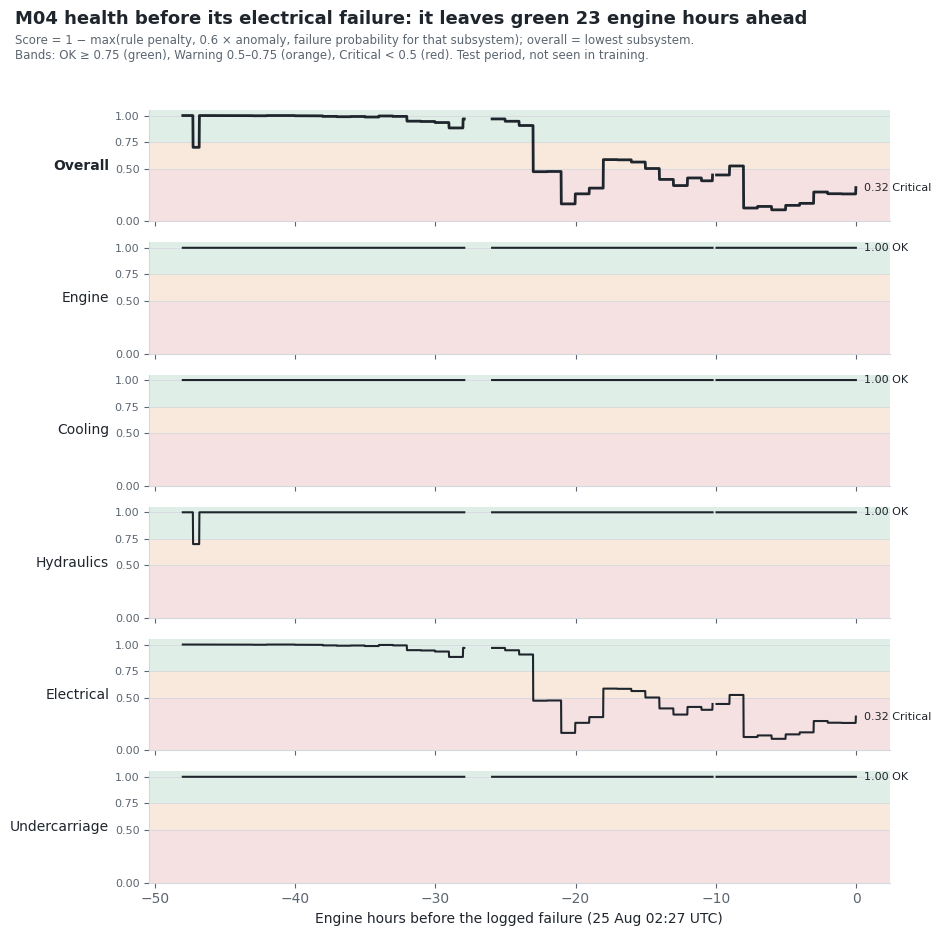

In [8]:
panels = ["overall", *H.SUBSYSTEMS]
fig, axes = plt.subplots(len(panels), 1, figsize=(10, 9.5), sharex=True)
x = health.h_before.to_numpy()
gap = np.r_[False, np.diff(x) > 5 / 60]  # break the line across off-shift gaps
for ax, col in zip(axes, panels):
    # Status bands as background tints, labelled with their word (colour is never alone)
    for lo, hi, b in [(H.GREEN_MIN, 1.05, "green"), (H.ORANGE_MIN, H.GREEN_MIN, "orange"), (0, H.ORANGE_MIN, "red")]:
        ax.axhspan(lo, hi, color=STATUS[b], alpha=0.14, lw=0)
    y = health[col].to_numpy(dtype=float)
    xs, ys = np.insert(x, np.flatnonzero(gap), np.nan), np.insert(y, np.flatnonzero(gap), np.nan)
    ax.plot(xs, ys, color=INK, lw=2 if col == "overall" else 1.5, solid_joinstyle="round")
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.5, 0.75, 1])
    ax.grid(axis="y", color=GRID, lw=0.6)
    ax.set_ylabel(col.capitalize(), rotation=0, ha="right", va="center",
                  fontweight="bold" if col == "overall" else "normal")
    ax.tick_params(axis="y", labelsize=8)
    end = y[-1]
    ax.annotate(f"{end:.2f} {STATUS_WORD[H.band(end)]}", (x[-1], end), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=8, color=INK)
axes[-1].set_xlabel(f"Engine hours before the logged failure ({fail.failure_ts:%d %b %H:%M} UTC)")
fig.suptitle(f"{MID} health before its {fail.component} failure: it leaves green 23 engine hours ahead",
             x=0.02, ha="left", fontsize=13, color=INK, fontweight="bold")
fig.text(0.02, 0.928, "Score = 1 − max(rule penalty, 0.6 × anomaly, failure probability for that subsystem); "
         "overall = lowest subsystem.\nBands: OK ≥ 0.75 (green), Warning 0.5–0.75 (orange), Critical < 0.5 (red). "
         "Test period, not seen in training.", fontsize=8.5, color=MUTED)
fig.tight_layout(rect=(0, 0, 0.95, 0.925))
fig.savefig(ART_H / "health_before_failure.png", dpi=150)
plt.show()

## 2 · Plan re-evaluation when rain starts

Candidates: test-period hours where rain crosses **2 mm/h** (previous hour ≤ 2) while a shift has run
≥ 1.5 h and has ≥ 3 h left. At that moment every task's status follows its actual times: finished → done,
started → `in_progress`, not started → `scheduled`. The same remaining tasks are then planned twice at the same moment:

* **before:** conditions of the dry hour before,
* **after:** the rainy hour's conditions (rain, visibility, wind…), with the `rain` trigger from `detect_triggers`.

The shift shown is the first candidate where rain moves an extra task to the next shift. The first one where
nothing changes is printed too, for contrast.

In [9]:
tasks = pd.read_csv(DATA / "tasks.csv", parse_dates=["scheduled_start", "actual_start", "actual_end"])
weather = pd.read_csv(DATA / "weather.csv", parse_dates=["ts"]).sort_values("ts")
shifts_t = pd.read_csv(DATA / "shifts.csv", parse_dates=["start_time", "end_time"])
operators = pd.read_csv(DATA / "operators.csv").drop(columns=["personality"])  # hidden generator field
fatigue = pd.read_csv(DATA / "fatigue_log.csv", parse_dates=["ts"])
mlog_t = pd.read_csv(DATA / "maintenance_log.csv", parse_dates=["event_date"])
tt_art = T.load_artifacts()
F = T.build_feature_table(tasks, weather, operators, machines, shifts_t, fatigue, mlog_t, tt_art["reference"])
F = F.merge(tasks[["task_id", "priority", "sequence_no", "actual_start", "predicted_p50_min"]], on="task_id")
print(F.shape)

(7213, 35)


In [10]:
def state_at(shift_id, now):
    # Task rows of a shift with their status at `now`, from the actual times
    t = F[(F.shift_id == shift_id) & (F.status != "cancelled")].copy()
    done = t.actual_end.notna() & (t.actual_end <= now)
    started = t.actual_start.notna() & (t.actual_start <= now)
    t["status"] = np.select([done, started], ["completed", "in_progress"], "scheduled")
    t.loc[t.status != "in_progress", "actual_start"] = pd.NaT
    return t.sort_values("sequence_no")

def conditions(site_id, ts):
    row = weather[(weather.site_id == site_id) & (weather.ts <= ts)].iloc[-1]
    return {c: float(row[c]) for c in T.WEATHER_COLUMNS}

w_ = weather.copy()
w_["prev"] = w_.groupby("site_id").rain_mm.shift()
starts = w_[(w_.rain_mm > P.RAIN_MM_H) & (w_.prev <= P.RAIN_MM_H) & (w_.ts >= TEST_START)]
cands = []
for _, r in starts.iterrows():
    live = shifts_t[(shifts_t.site_id == r.site_id) & (shifts_t.start_time + pd.Timedelta(hours=1.5) <= r.ts)
                    & (shifts_t.end_time - pd.Timedelta(hours=3) >= r.ts)]
    for _, s in live.iterrows():
        t = state_at(s.shift_id, r.ts)
        if (t.status != "completed").sum() < 3:
            continue
        dry, wet = conditions(s.site_id, r.ts - pd.Timedelta(hours=1)), conditions(s.site_id, r.ts)
        trig = P.detect_triggers(now=r.ts, rain_mm_h=wet["rain_mm"])
        before = P.re_evaluate_plan(s.shift_id, t, r.ts, s.end_time, s.start_time, dry)
        after = P.re_evaluate_plan(s.shift_id, t, r.ts, s.end_time, s.start_time, wet, reason=trig)
        cands.append({"shift_id": s.shift_id, "now": r.ts, "rain_mm": wet["rain_mm"], "shift": s, "tasks": t,
                      "dry": dry, "wet": wet, "before": before, "after": after,
                      "changed": after["moved_to_next_shift"] != before["moved_to_next_shift"]
                                 or after["new_order"] != before["new_order"]})
summary = pd.DataFrame([{k: c[k] for k in ("shift_id", "now", "rain_mm", "changed")}
                        | {"moved_before": len(c["before"]["moved_to_next_shift"]),
                           "moved_after": len(c["after"]["moved_to_next_shift"])} for c in cands])
print(f"{len(cands)} candidate shifts, {summary.changed.sum()} where the rain changes the plan")
summary

15 candidate shifts, 5 where the rain changes the plan


,shift_id,now,rain_mm,changed,moved_before,moved_after
0,SH-2026-08-21-M07-N,2026-08-21 16:30:00+00:00,9.30,True,0,1
1,SH-2026-08-21-M09-N,2026-08-21 16:30:00+00:00,9.30,True,0,1
2,SH-2026-08-24-M09-N,2026-08-24 15:30:00+00:00,2.99,False,1,1
3,SH-2026-08-26-M02-D,2026-08-26 05:30:00+00:00,4.53,False,1,1
4,SH-2026-08-26-M05-D,2026-08-26 05:30:00+00:00,4.53,False,1,1
5,SH-2026-08-26-M04-D,2026-08-26 05:30:00+00:00,4.53,True,0,1
6,SH-2026-08-27-M07-D,2026-08-27 04:30:00+00:00,3.22,False,1,1
7,SH-2026-08-27-M12-D,2026-08-27 04:30:00+00:00,3.22,False,1,1
8,SH-2026-08-27-M10-D,2026-08-27 04:30:00+00:00,3.22,False,1,1
9,SH-2026-08-28-M07-N,2026-08-28 15:30:00+00:00,11.90,False,0,0


In [11]:
pick = next(c for c in cands
            if len(c["after"]["moved_to_next_shift"]) > len(c["before"]["moved_to_next_shift"]))
same = next((c for c in cands if not c["changed"]), None)
print("Re-planned shift:", pick["shift_id"], "| rain", pick["rain_mm"], "mm/h at",
      pick["now"].tz_convert(IST).strftime("%d %b %H:%M IST"))
print("dry:", {k: round(v, 1) for k, v in pick["dry"].items()})
print("wet:", {k: round(v, 1) for k, v in pick["wet"].items()})
print("\nBefore:", pick["before"]["explanation"])
print("After: ", pick["after"]["explanation"])
if same is not None:
    print(f"\nNo change for {same['shift_id']}: {same['after']['explanation']}")
api = {k: pick["after"][k] for k in ("shift_id", "fits", "moved_to_next_shift", "new_order", "explanation")}
print(json.dumps(api, indent=1))

Re-planned shift: SH-2026-08-21-M07-N | rain 9.3 mm/h at 21 Aug 22:00 IST
dry: {'temp_c': 31.3, 'rain_mm': 0.0, 'wind_kmh': 9.0, 'visibility_m': 8000.0, 'dust_index': 0.3}
wet: {'temp_c': 28.1, 'rain_mm': 9.3, 'wind_kmh': 6.4, 'visibility_m': 3881.6, 'dust_index': 0.1}

Before: All remaining tasks still fit before 02:00. New order: task 3, task 5, task 4.
After:  Rain started. Task 4 no longer fits before 02:00; it moves to the next shift.

No change for SH-2026-08-24-M09-N: Rain started. Task 3 no longer fits before 02:00; it moves to the next shift.
{
 "shift_id": "SH-2026-08-21-M07-N",
 "fits": [
  "T-SH-2026-08-21-M07-N-3",
  "T-SH-2026-08-21-M07-N-5"
 ],
 "moved_to_next_shift": [
  "T-SH-2026-08-21-M07-N-4"
 ],
 "new_order": [
  "T-SH-2026-08-21-M07-N-3",
  "T-SH-2026-08-21-M07-N-5"
 ],
 "explanation": "Rain started. Task 4 no longer fits before 02:00; it moves to the next shift."
}


In [12]:
# Per task: p50 in dry vs rainy conditions, and what actually happened
b = {s["task_id"]: s for s in pick["before"]["schedule"]}
a = {s["task_id"]: s for s in pick["after"]["schedule"]}
t = pick["tasks"].set_index("task_id")
actual = tasks.set_index("task_id")
table = pd.DataFrame([{
    "task": f"task {int(t.loc[i, 'sequence_no'])}", "type": f"{t.loc[i, 'task_type']} {t.loc[i, 'material_type']}",
    "priority": int(t.loc[i, "priority"]), "status_now": t.loc[i, "status"],
    "p50_dry": b[i]["p50_min"], "p50_rain": a[i]["p50_min"],
    "fits_dry": b[i]["fits"], "fits_rain": a[i]["fits"],
    "actual_min": actual.loc[i, "actual_duration_min"], "actual_status": actual.loc[i, "status"],
} for i in a])
table

,task,type,priority,status_now,p50_dry,p50_rain,fits_dry,fits_rain,actual_min,actual_status
0,task 3,load rock,2,in_progress,74.6,90.3,True,True,72.9,completed
1,task 5,dig rock,1,scheduled,106.6,125.2,True,True,97.9,completed
2,task 4,load gravel,3,scheduled,53.3,65.5,True,False,61.9,completed


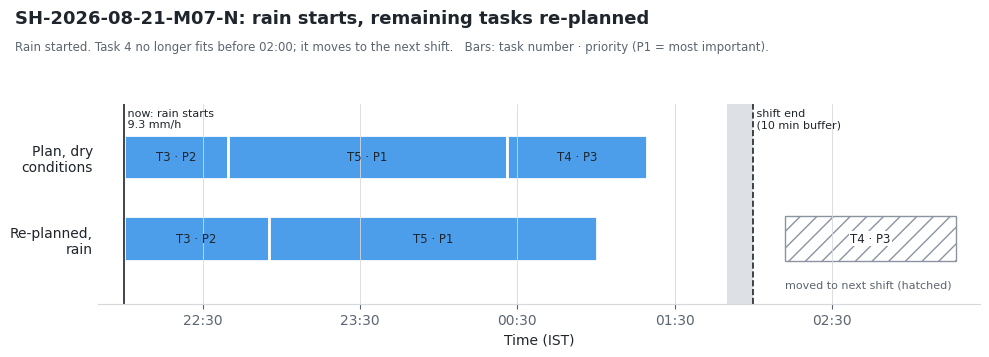

In [13]:
def gantt(ax, plan, y, end):
    # One row: planned tasks in steel; moved tasks hatched, after the shift end
    xmove = end + pd.Timedelta(minutes=12)
    for s in plan["schedule"]:
        lab = f"T{s['task_id'].rsplit('-', 1)[-1]} · P{s['priority']}"
        if s["fits"]:
            x0, x1 = pd.Timestamp(s["start"]), pd.Timestamp(s["end"])
            ax.barh(y, x1 - x0, left=x0, height=0.55, color=STEEL, edgecolor="white", linewidth=2)
            ax.text(x0 + (x1 - x0) / 2, y, lab, ha="center", va="center", fontsize=8.5, color=INK)
        else:
            dur = pd.Timedelta(minutes=s["p50_min"] or 30)
            ax.barh(y, dur, left=xmove, height=0.55, color="white", edgecolor=SLATE, hatch="//", linewidth=1)
            ax.text(xmove + dur / 2, y, lab, ha="center", va="center", fontsize=8.5, color=INK,
                    bbox=dict(fc="white", ec="none", pad=1))
            xmove += dur + pd.Timedelta(minutes=4)
    return xmove

s, now = pick["shift"], pick["now"]
fig, ax = plt.subplots(figsize=(10, 3.6))
rightmost = max(gantt(ax, pick["before"], 1, s.end_time), gantt(ax, pick["after"], 0, s.end_time))
ax.axvline(now, color=INK, lw=1.2)
ax.text(now, 1.6, f" now: rain starts\n {pick['rain_mm']:.1f} mm/h", fontsize=8, va="top", color=INK)
ax.axvspan(s.end_time - pd.Timedelta(minutes=P.BUFFER_MIN), s.end_time, color=GRID, alpha=0.8, lw=0)
ax.axvline(s.end_time, color=INK, lw=1.2, ls="--")
ax.text(s.end_time, 1.6, " shift end\n (10 min buffer)", fontsize=8, va="top", color=INK)
ax.text(s.end_time + pd.Timedelta(minutes=12), -0.6, "moved to next shift (hatched)", fontsize=8, color=MUTED)
ax.set_yticks([1, 0], ["Plan, dry\nconditions", "Re-planned,\nrain"])
ax.set_ylim(-0.8, 1.65)
ax.set_xlim(now - pd.Timedelta(minutes=10), rightmost + pd.Timedelta(minutes=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=IST))
ax.set_xlabel("Time (IST)")
ax.grid(axis="x", color=GRID, lw=0.6)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0, labelcolor=INK)
fig.suptitle(f"{pick['shift_id']}: rain starts, remaining tasks re-planned", x=0.02, ha="left",
             fontsize=13, color=INK, fontweight="bold")
fig.text(0.02, 0.865, pick["after"]["explanation"] + "   Bars: task number · priority (P1 = most important).", fontsize=8.5, color=MUTED)
fig.tight_layout(rect=(0, 0, 1, 0.85))
fig.savefig(ART_P / "replan_rain.png", dpi=150)
plt.show()

## Notes

* Health: the anomaly term counts only on `machine_fault` minutes (normal minutes score p90 ≈ 0.49 and would
  keep turning subsystems orange). Rule states here are a stateless approximation; the backend's rule engine replaces them live.
* Plan: `hours_into_shift` is set to *now* for every remaining task (their start times depend on the order
  being decided). The task-time model's late-shift and night p50s are optimistic (models.md §2), so
  re-planning late in a shift tends to fit slightly more than will really finish.